In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("archivee3.csv")

In [3]:
df.head()

,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060


In [4]:
df.shape

(30000, 19)

In [5]:
df.shape

(30000, 19)

In [6]:
df.columns

Index(['age', 'gender', 'job_type', 'daily_social_media_time',
       'social_platform_preference', 'number_of_notifications',
       'work_hours_per_day', 'perceived_productivity_score',
       'actual_productivity_score', 'stress_level', 'sleep_hours',
       'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps',
       'has_digital_wellbeing_enabled', 'coffee_consumption_per_day',
       'days_feeling_burnout_per_month', 'weekly_offline_hours',
       'job_satisfaction_score'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      30000 non-null  object 
 5   number_of_notifications         30000 non-null  int64  
 6   work_hours_per_day              30000 non-null  float64
 7   perceived_productivity_score    28386 non-null  float64
 8   actual_productivity_score       27635 non-null  float64
 9   stress_level                    28096 non-null  float64
 10  sleep_hours                     27402 non-null  float64
 11  screen_time_before_sleep        27789 non-null  float64
 12  breaks_during_work              

In [8]:
df.describe()

,age,daily_social_media_time,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
count,30000.000000,27235.000000,30000.000000,30000.000000,28386.000000,27635.000000,28096.000000,27402.000000,27789.000000,30000.000000,30000.000000,30000.000000,30000.000000,27270.000000
mean,41.486867,3.113418,59.958767,6.990792,5.510488,4.951805,5.514059,6.500247,1.025568,4.992200,1.999300,15.557067,10.360655,4.964901
std,13.835221,2.074813,7.723772,1.997736,2.023470,1.883378,2.866344,1.464004,0.653355,3.173737,1.410047,9.252956,7.280415,2.121194
min,18.000000,0.000000,30.000000,0.000000,2.000252,0.296812,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.639566,55.000000,5.643771,3.757861,3.373284,3.000000,5.493536,0.528490,2.000000,1.000000,8.000000,4.541872,3.363580
50%,41.000000,3.025913,60.000000,6.990641,5.525005,4.951742,6.000000,6.498340,1.006159,5.000000,2.000000,16.000000,10.013677,4.951049
75%,53.000000,4.368917,65.000000,8.354725,7.265776,6.526342,8.000000,7.504143,1.477221,8.000000,3.000000,24.000000,15.300809,6.581323
max,65.000000,17.973256,90.000000,12.000000,8.999376,9.846258,10.000000,10.000000,3.000000,10.000000,10.000000,31.000000,40.964769,10.000000


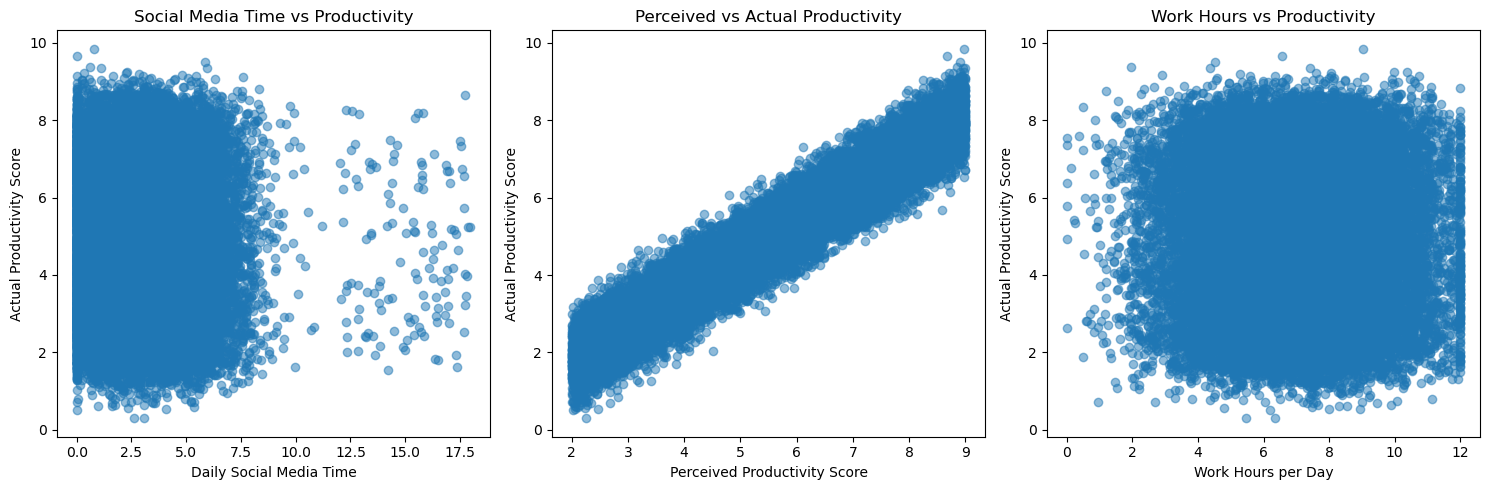

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(
    df["daily_social_media_time"],
    df["actual_productivity_score"],
    alpha=0.5
)
plt.xlabel("Daily Social Media Time")
plt.ylabel("Actual Productivity Score")
plt.title("Social Media Time vs Productivity")

plt.subplot(1, 3, 2)
plt.scatter(
    df["perceived_productivity_score"],
    df["actual_productivity_score"],
    alpha=0.5
)
plt.xlabel("Perceived Productivity Score")
plt.ylabel("Actual Productivity Score")
plt.title("Perceived vs Actual Productivity")

plt.subplot(1, 3, 3)
plt.scatter(
    df["work_hours_per_day"],
    df["actual_productivity_score"],
    alpha=0.5
)
plt.xlabel("Work Hours per Day")
plt.ylabel("Actual Productivity Score")
plt.title("Work Hours vs Productivity")

plt.tight_layout()
plt.show()

In [10]:
features = [
    "perceived_productivity_score",
    "stress_level",
    "sleep_hours",
    "screen_time_before_sleep",
    "breaks_during_work",
    "daily_social_media_time",
    "number_of_notifications",
    "work_hours_per_day",
    "coffee_consumption_per_day",
    "days_feeling_burnout_per_month",
    "weekly_offline_hours",
    "job_satisfaction_score",
    "age"
]

target = "actual_productivity_score"

In [11]:
model_df = df[features + [target]].dropna()

In [12]:
X = model_df[features]
y = model_df[target]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [14]:
model = LinearRegression()

In [15]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred = model.predict(X_test)

In [17]:
comparison = pd.DataFrame({
    "Actual Productivity": y_test.values,
    "Predicted Productivity": y_pred
})

print(comparison.head(10))

   Actual Productivity  Predicted Productivity
0             2.321966                2.526245
1             6.639901                6.249250
2             2.423302                2.643048
3             2.643793                2.189521
4             3.242198                3.859168
5             3.227520                2.791784
6             5.376428                5.598926
7             6.718962                7.034582
8             4.034595                3.754778
9             4.935839                5.294482


In [18]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

                           Feature  Coefficient
0     perceived_productivity_score     0.721694
1                     stress_level    -0.001098
2                      sleep_hours     0.004013
3         screen_time_before_sleep    -0.002075
4               breaks_during_work    -0.000773
5          daily_social_media_time    -0.000722
6          number_of_notifications     0.000482
7               work_hours_per_day    -0.005256
8       coffee_consumption_per_day     0.002050
9   days_feeling_burnout_per_month     0.000179
10            weekly_offline_hours    -0.000643
11          job_satisfaction_score     0.197018
12                             age     0.000013


In [19]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 3))
print("R² Score:", round(r2, 3))
print("R² Percentage:", round(r2 * 100, 2), "%")

Mean Squared Error: 0.199
R² Score: 0.946
R² Percentage: 94.56 %


In [ ]:
import streamlit as st
import pandas as pd
from sklearn.linear_model import LinearRegression

st.set_page_config(
    page_title="Social Media Productivity Analyzer",
    page_icon="📊",
    layout="centered"
)

st.title("Social Media Productivity Analyzer")
st.write("Predict your actual productivity score")

df = pd.read_csv("archivee3.csv")

features = [
    "perceived_productivity_score",
    "stress_level",
    "sleep_hours",
    "screen_time_before_sleep",
    "breaks_during_work",
    "daily_social_media_time",
    "number_of_notifications",
    "work_hours_per_day",
    "coffee_consumption_per_day",
    "days_feeling_burnout_per_month",
    "weekly_offline_hours",
    "job_satisfaction_score",
    "age"
]

df = df[features + ["actual_productivity_score"]].dropna()

X = df[features]
y = df["actual_productivity_score"]

model = LinearRegression()
model.fit(X, y)

st.subheader("Enter Your Details")

values = []

for feature in features:
    value = st.number_input(feature.replace("_", " ").title())
    values.append(value)

if st.button("Predict Productivity"):
    prediction = model.predict([values])
    st.success(f"Predicted Productivity Score: {prediction[0]:.2f}")

In [21]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
